# Merge E-OBS (PP, RR, TG) with SPI-1 and WDF

Combines processed E-OBS datasets: pressure, precipitation, temperature, wet-day frequency, SPI-1.
Adds lagged variables. Output: `2_eobs_pp_tg_rr_spi_wdf_df.csv`.

In [108]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import eobs
import pandas as pd
import os

# Load Data (SPI-1)

In [ ]:
folder = "000000 Final Data/eastnor"
filename = "1_eobs_eastnor_spi_1_values.nc"

eobs_xr = xr.open_dataset(os.path.join(folder, filename))
eobs_xr

<xarray.Dataset> Size: 8kB
Dimensions:       (year: 75, month: 12)
Coordinates:
  * year          (year) int64 600B 1950 1951 1952 1953 ... 2021 2022 2023 2024
  * month         (month) <U9 432B 'January' 'February' ... 'December'
Data variables:
    spi_1_values  (year, month) float64 7kB ...

In [ ]:
eobs_df = eobs_xr.to_dataframe().reset_index()

eobs_df["time"] = pd.to_datetime(eobs_df["year"].astype(str) + "-" + eobs_df["month"], format="%Y-%B")

eobs_df["time"] = eobs_df["time"] + pd.offsets.MonthEnd(0)

eobs_df = eobs_df.drop(columns=["year", "month"])

eobs_df.set_index("time", inplace=True)
eobs_df

,spi_1_values
time,
1950-01-31,0.218453
1950-02-28,0.860808
1950-03-31,-0.966382
1950-04-30,1.071493
1950-05-31,-0.230906
...,...
2024-08-31,NaN
2024-09-30,NaN
2024-10-31,NaN


In [ ]:
# Print which dates (index) have NaN in any column
eobs_df[eobs_df.isna().any(axis=1)]

spi_1_values    6
dtype: int64


,spi_1_values
time,
2024-07-31,NaN
2024-08-31,NaN
2024-09-30,NaN
2024-10-31,NaN
2024-11-30,NaN
2024-12-31,NaN


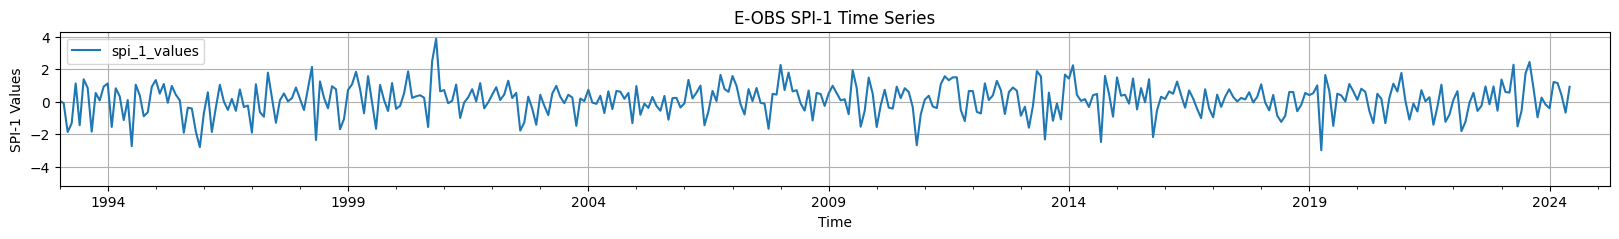

In [112]:
eobs_df.plot(kind='line', figsize=(20, 2), title='E-OBS SPI-1 Time Series')
plt.xlabel('Time')
plt.xlim(pd.Timestamp('1993-01-31'), pd.Timestamp('2025-04-30'))
plt.ylabel('SPI-1 Values')
plt.grid(True)
plt.show()

# Load Data (E-OBS + RainRate)

__pp:__ Average monthly precipitation (mm), averaged over gridcells  
__rr:__ Summed monthly precipitation (mm), averaged over gridcells  
__tg:__ Average monthly temperature (°C), averaged over gridcells  
__rainy_days_rate:__ Proportion of rainy days in the month  

In [ ]:
folder = "000000 Final Data/eastnor"

# File paths
filenames = {
    "pp": "1_eobs_pp_eastnor_avgmonthly_avgloc.nc",
    "rr": "1_eobs_rr_eastnor_summonthly_avgloc.nc",
    "tg": "1_eobs_tg_eastnor_avgmonthly_avgloc.nc",
    "wet_day_frequency": "1_eobs_wdf_eastnor_1993_monthly_avgloc.nc"
}

datasets = {key: xr.open_dataset(os.path.join(folder, filename)) for key, filename in filenames.items()}
datasets_info = {key: ds for key, ds in datasets.items()}

In [ ]:
# Convert xarray datasets to pandas DataFrame
df = pd.DataFrame({
    "time": datasets["pp"]["time"].values,
    "pp": datasets["pp"]["pp"].values,
    "rr": datasets["rr"]["rr"].values,
    "tg": datasets["tg"]["tg"].values,
    "wet_day_frequency": datasets["wet_day_frequency"]["wet_day_frequency"].values,
})

df.set_index("time", inplace=True)
df

,pp,rr,tg,wet_day_frequency
time,,,,
1993-01-31,998.947327,38.970314,-5.261134,0.391633
1993-02-28,1018.138611,25.704689,-4.456501,0.235491
1993-03-31,1014.497620,6.095313,-3.907354,0.121976
1993-04-30,1014.269165,9.868751,0.896708,0.151042
1993-05-31,1015.968872,82.575005,7.252682,0.433972
...,...,...,...,...
2024-02-29,1004.466614,49.915627,-7.269413,0.451509
2024-03-31,1011.474121,52.109375,-2.567913,0.491935
2024-04-30,1010.797607,34.868752,-0.065708,0.356771


In [ ]:
df_summary = df.describe(include="all")
df_summary

,pp,rr,tg,wet_day_frequency
count,378.000000,378.000000,378.000000,378.000000
mean,1011.462769,57.654934,1.536926,0.392478
std,5.682230,33.762589,7.575235,0.136554
min,992.238403,1.942188,-14.924833,0.036458
25%,1008.780869,32.815233,-5.097682,0.303931
50%,1011.474945,51.240625,0.803534,0.387667
75%,1014.698288,77.189455,8.330981,0.471669
max,1029.921631,219.917175,16.586060,0.791146


In [ ]:
nan_rows = df[df.isna().any(axis=1)]
print("Rows containing at least one NaN value:")
nan_rows

Rows containing at least one NaN value:


,pp,rr,tg,wet_day_frequency
time,,,,


# Add EOBS to the Dataset above

In [117]:
# Merge eobs_df into df again, ensuring proper alignment
df_merged = df.merge(eobs_df, on="time", how="outer")
df_merged

,pp,rr,tg,wet_day_frequency,spi_1_values
time,,,,,
1950-01-31,NaN,NaN,NaN,NaN,0.218453
1950-02-28,NaN,NaN,NaN,NaN,0.860808
1950-03-31,NaN,NaN,NaN,NaN,-0.966382
1950-04-30,NaN,NaN,NaN,NaN,1.071493
1950-05-31,NaN,NaN,NaN,NaN,-0.230906
...,...,...,...,...,...
2024-08-31,NaN,NaN,NaN,NaN,NaN
2024-09-30,NaN,NaN,NaN,NaN,NaN
2024-10-31,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_merged.isna().sum(axis=1)
df_merged.isna().sum()
df_merged.isna().sum(axis=0)

pp                   522
rr                   522
tg                   522
wet_day_frequency    522
spi_1_values           6
dtype: int64

In [ ]:
df_merged_1993 = df_merged[df_merged["pp"].first_valid_index():df_merged["pp"].last_valid_index()]
df_merged_1993

,pp,rr,tg,wet_day_frequency,spi_1_values
time,,,,,
1993-01-31,998.947327,38.970314,-5.261134,0.391633,0.051676
1993-02-28,1018.138611,25.704689,-4.456501,0.235491,-0.085867
1993-03-31,1014.497620,6.095313,-3.907354,0.121976,-1.862051
1993-04-30,1014.269165,9.868751,0.896708,0.151042,-1.329268
1993-05-31,1015.968872,82.575005,7.252682,0.433972,1.124866
...,...,...,...,...,...
2024-02-29,1004.466614,49.915627,-7.269413,0.451509,1.212234
2024-03-31,1011.474121,52.109375,-2.567913,0.491935,1.148224
2024-04-30,1010.797607,34.868752,-0.065708,0.356771,0.386026


### WHERE ARE NAN?

In [121]:
# Print only rows with NAN values
nan_rows = df_merged_1993[df_merged_1993.isna().any(axis=1)]
nan_rows

,pp,rr,tg,wet_day_frequency,spi_1_values
time,,,,,


### DESCRIBE

One sees that the period 1993-2024 have higher relative precipitation than 1950 to 2024 (given the higher mean)

In [ ]:
df_merged_1993.describe(include="all")

,pp,rr,tg,wet_day_frequency,spi_1_values
count,378.000000,378.000000,378.000000,378.000000,378.000000
mean,1011.462769,57.654934,1.536926,0.392478,0.126850
std,5.682230,33.762589,7.575235,0.136554,0.979400
min,992.238403,1.942188,-14.924833,0.036458,-2.982115
25%,1008.780869,32.815233,-5.097682,0.303931,-0.430588
50%,1011.474945,51.240625,0.803534,0.387667,0.236073
75%,1014.698288,77.189455,8.330981,0.471669,0.721876
max,1029.921631,219.917175,16.586060,0.791146,3.875648


# Create lagged variables

### FIRST CHECK IF ALL MONTHS ARE REPRESENTED

In [ ]:
months_in_data = df_merged_1993.index.month

all_months = set(range(1, 13))
months_missing = all_months - set(months_in_data)

month_counts = months_in_data.value_counts().sort_index()
date_diffs = df_merged_1993.index.to_series().diff().dropna()
months_shifted = months_in_data.values[1:]
months_current = months_in_data.values[:-1]
correct = [
    (curr == prev + 1) or (prev == 12 and curr == 1)
    for prev, curr in zip(months_current, months_shifted)
]

if hasattr(df_merged_1993.index, "year") and hasattr(df_merged_1993.index, "month"):
    ct = df_merged_1993.groupby([df_merged_1993.index.year, df_merged_1993.index.month]).size().unstack(fill_value=0)
    print("\nYear-month crosstab (should be all ones):")
    display(ct)

All months from 1 to 12 are represented in df_merged_1993.
Months in df_merged_1993 are in correct order.

Year-month crosstab (should be all ones):


time,1,2,3,4,5,6,7,8,9,10,11,12
time,,,,,,,,,,,,
1993,1,1,1,1,1,1,1,1,1,1,1,1
1994,1,1,1,1,1,1,1,1,1,1,1,1
1995,1,1,1,1,1,1,1,1,1,1,1,1
1996,1,1,1,1,1,1,1,1,1,1,1,1
1997,1,1,1,1,1,1,1,1,1,1,1,1
1998,1,1,1,1,1,1,1,1,1,1,1,1
1999,1,1,1,1,1,1,1,1,1,1,1,1
2000,1,1,1,1,1,1,1,1,1,1,1,1
2001,1,1,1,1,1,1,1,1,1,1,1,1


### THEN CREATE TE LAGGED PARAMETERS

In [ ]:
df = df_merged_1993.copy()

# Define lags for pp, tg, and rr
for lag in [1, 2]:
    df[f"pp_-{lag}"] = df["pp"].shift(lag)
    df[f"tg_-{lag}"] = df["tg"].shift(lag)
    df[f"rr_-{lag}"] = df["rr"].shift(lag)

df.head()

,pp,rr,tg,wet_day_frequency,spi_1_values,pp_-1,tg_-1,rr_-1,pp_-2,tg_-2,rr_-2
time,,,,,,,,,,,
1993-01-31,998.947327,38.970314,-5.261134,0.391633,0.051676,NaN,NaN,NaN,NaN,NaN,NaN
1993-02-28,1018.138611,25.704689,-4.456501,0.235491,-0.085867,998.947327,-5.261134,38.970314,NaN,NaN,NaN
1993-03-31,1014.497620,6.095313,-3.907354,0.121976,-1.862051,1018.138611,-4.456501,25.704689,998.947327,-5.261134,38.970314
1993-04-30,1014.269165,9.868751,0.896708,0.151042,-1.329268,1014.497620,-3.907354,6.095313,1018.138611,-4.456501,25.704689
1993-05-31,1015.968872,82.575005,7.252682,0.433972,1.124866,1014.269165,0.896708,9.868751,1014.497620,-3.907354,6.095313


# Sort columns alphabetically & add "eobs_" as prefix

In [ ]:
df = df.reindex(sorted(df.columns), axis=1)

df = df[[col for col in df.columns if col not in ["wet_day_frequency", "spi_1_values"]] + ["wet_day_frequency", "spi_1_values"]]

df.columns = ["eobs_" + col for col in df.columns]
df.head()

,eobs_pp,eobs_pp_-1,eobs_pp_-2,eobs_rr,eobs_rr_-1,eobs_rr_-2,eobs_tg,eobs_tg_-1,eobs_tg_-2,eobs_wet_day_frequency,eobs_spi_1_values
time,,,,,,,,,,,
1993-01-31,998.947327,NaN,NaN,38.970314,NaN,NaN,-5.261134,NaN,NaN,0.391633,0.051676
1993-02-28,1018.138611,998.947327,NaN,25.704689,38.970314,NaN,-4.456501,-5.261134,NaN,0.235491,-0.085867
1993-03-31,1014.497620,1018.138611,998.947327,6.095313,25.704689,38.970314,-3.907354,-4.456501,-5.261134,0.121976,-1.862051
1993-04-30,1014.269165,1014.497620,1018.138611,9.868751,6.095313,25.704689,0.896708,-3.907354,-4.456501,0.151042,-1.329268
1993-05-31,1015.968872,1014.269165,1014.497620,82.575005,9.868751,6.095313,7.252682,0.896708,-3.907354,0.433972,1.124866
